<a href="https://colab.research.google.com/github/aryann25-cmd/BA820-Childcare-Programming-Analysis/blob/main/M4_YashaswiniReddy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BA820 – M4
## Uncovering Latent Structures in Childcare Affordability and Cost Dynamics Across U.S. Counties

Yashaswini Reddy Vari

U01881813

A1 – Team 13  
**GitHub:** https://github.com/aryann25-cmd/BA820-Childcare-Programming-Analysis

---


This milestone aims to deepen the trajectory-based clustering from M2 including,
1. Individual county-level trend plots
2. Formal cluster profiling with summary statistics
3. Quantitative k-selection: elbow + silhouette
4. Year-over-year change clustering
5. DBSCAN and Gaussian Mixture Model comparisons

---

### Table of Contents
1. Setup and Data Loading
2. M2 Preprocessing Reproduction
3. NEW: Individual County Trend Plots
4. Formal Cluster Profiling
5. NEW: Quantitative k-Selection
6. NEW: Year-over-Year Change Clustering
7. NEW: DBSCAN and Gaussian Mixture Model
8. Method Comparison Matrix
9. Findings & Interpretations
10. Gen AI disclosure

---
## 1. Setup and Data Loading

In [2]:
#package installation
!pip install -q seaborn scikit-learn matplotlib pandas numpy scipy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from scipy import stats
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, silhouette_samples, adjusted_rand_score
import warnings
warnings.filterwarnings('ignore')


plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3
})
CLUSTER_COLORS = ['#2C7BB6', '#D7191C', '#1A9641', '#FDAE61']
sns.set_style('whitegrid')
print('Libraries loaded.')

Libraries loaded.


In [3]:
# data loading
url = 'https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2023/2023-05-09/childcare_costs.csv'
df_childcare = pd.read_csv(url)
print(f'Shape: {df_childcare.shape} | Years: {df_childcare.study_year.min()}-{df_childcare.study_year.max()} | Counties: {df_childcare.county_fips_code.nunique():,}')

Shape: (34567, 61) | Years: 2008-2018 | Counties: 3,144


---
## 2. M2 Preprocessing Reproduction

**What is unchanged from M2:**  
- Filter to counties with full 2008–2018 coverage (3,140 counties)  
- Pivot to county × year matrix on `mcsa`  
- Engineer four trajectory features: `mean_cost`, `volatility`, `growth_08_18`, `trend_slope`  
- StandardScaler normalisation  
- K-Means k=4 primary segmentation  

**Why nothing changed in preprocessing:** These choices were validated by (1) hierarchical clustering alignment in M2, and (2) M3's chi-square cross-tabulation (x^2=264.5, p<0.0001) confirming trajectory type strongly predicts 2018 affordability profile. No new preprocessing is introduced in M4.


 All four M2 pipelines used StandardScaler and the same 3,140-county filtered base. For M3 integration, the inner join reduced the sample to 1,274 counties with complete data across all four analyses. M4 uses the full 3,140-county base for my individual analysis.

In [4]:
# Filtering to counties with complete 2008-2018 coverage
years_per_county = df_childcare.groupby('county_fips_code')['study_year'].nunique()
full_years = years_per_county.max()
valid_counties = years_per_county[years_per_county == full_years].index
df_full = df_childcare[df_childcare['county_fips_code'].isin(valid_counties)].copy()

print(f'Total counties         : {len(years_per_county):,}')
print(f'Full-coverage counties : {len(valid_counties):,}')

# county x year matrix pivot
pivot = df_full.pivot(index='county_fips_code', columns='study_year', values='mcsa').sort_index(axis=1)
print(f'Pivot shape            : {pivot.shape}')

Total counties         : 3,144
Full-coverage counties : 3,140
Pivot shape            : (3140, 11)


In [5]:
# Engineering trajectory features
trajectory_features = pd.DataFrame(index=pivot.index)
trajectory_features['mean_cost']    = pivot.mean(axis=1)
trajectory_features['volatility']   = pivot.std(axis=1)
trajectory_features['growth_08_18'] = (pivot[2018] - pivot[2008]) / pivot[2008]
trajectory_features['trend_slope']  = pivot[2018] - pivot[2008]
trajectory_features = trajectory_features.dropna()

# Standardising
scaler = StandardScaler()
X_traj = scaler.fit_transform(trajectory_features)

# K-Means k=4 (taken from M2)
kmeans_k4 = KMeans(n_clusters=4, random_state=42, n_init=10)
trajectory_features['cluster'] = kmeans_k4.fit_predict(X_traj)

order = trajectory_features.groupby('cluster')['mean_cost'].mean().sort_values().index
lmap  = {old: new for new, old in enumerate(order)}
trajectory_features['cluster'] = trajectory_features['cluster'].map(lmap)

CLUSTER_LABELS = {0:'Low-Cost Stable', 1:'Moderate-Cost Slow-Growth',
                  2:'Moderate-Cost High-Growth', 3:'High-Cost Volatile'}
print('K-Means k=4 cluster counts:')
for c, n in trajectory_features['cluster'].value_counts().sort_index().items():
    print(f'  Cluster {c} ({CLUSTER_LABELS[c]}): {n} counties')

K-Means k=4 cluster counts:
  Cluster 0 (Low-Cost Stable): 576 counties
  Cluster 1 (Moderate-Cost Slow-Growth): 397 counties
  Cluster 2 (Moderate-Cost High-Growth): 275 counties
  Cluster 3 (High-Cost Volatile): 26 counties


---
## 3. NEW: Trend plots of individual counties



**Approach:** For each of the four trajectory clusters, I selected,

(a) the county closest to the cluster centroid on mean_cost, and

(b) the county with the highest mean_cost in the cluster.

Their year-by-year `mcsa` values are plotted against the cluster average and national average.

National averages show that childcare costs rose from  90/wk in  2008 to 112/wk by 2018, a 24% increase. But a High-Cost Volatile county may have gone from $150 to $300 over the same period, while a Low-Cost Stable county went from $70 to $80. These are fundamentally different economic realities for families and they require different policy responses. Individual plots make this viscerally clear.

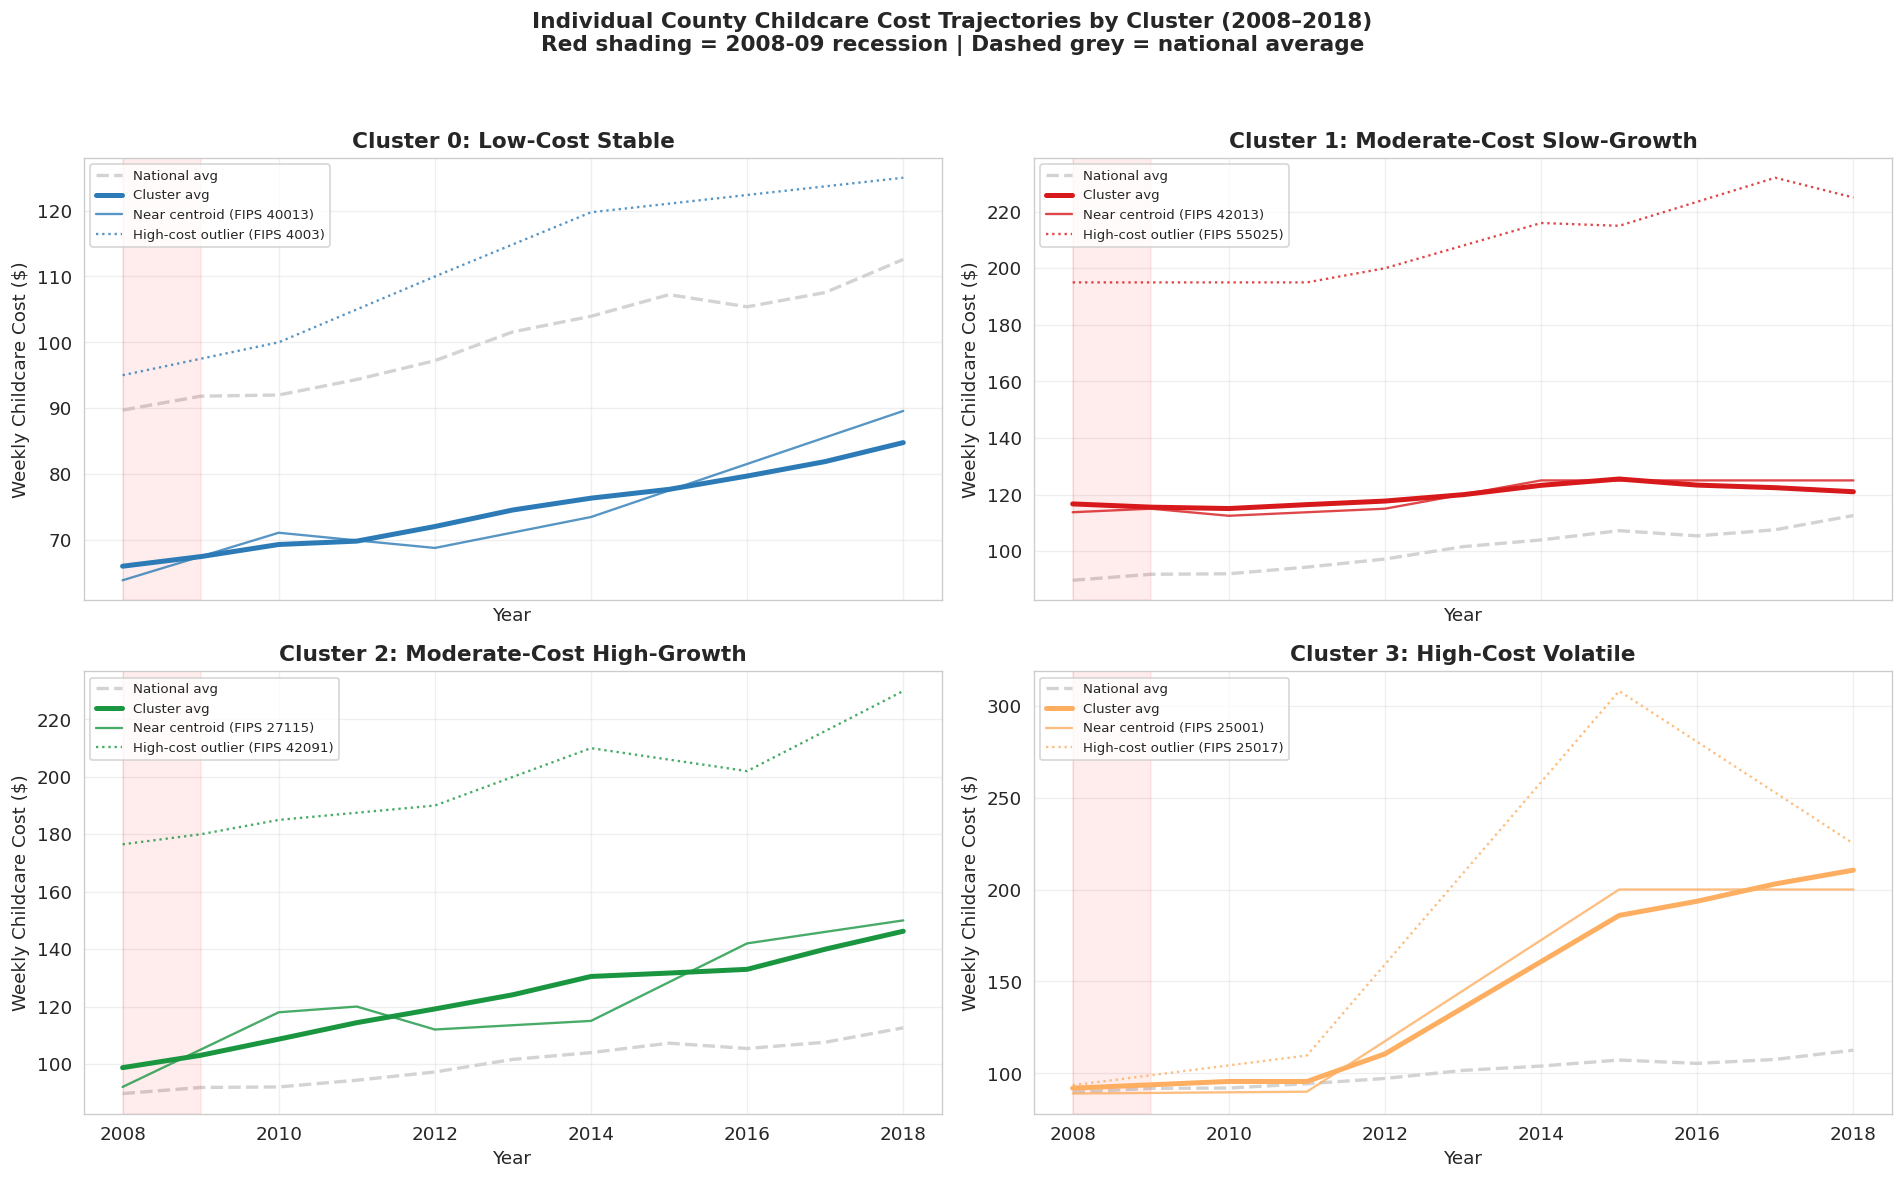

Figure 1: Individual county trend plots


In [6]:
years = [c for c in pivot.columns if isinstance(c, int)]
national_avg = pivot[years].mean(axis=0)

#Representative counties selection per cluster
selected = {}
for c in range(4):
    grp = trajectory_features[trajectory_features['cluster'] == c]
    centroid = grp['mean_cost'].mean()
    closest  = (grp['mean_cost'] - centroid).abs().nsmallest(1).index[0]
    highest  = grp['mean_cost'].nlargest(1).index[0]
    selected[c] = [closest, highest]

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)
axes = axes.flatten()

for c in range(4):
    ax = axes[c]
    cluster_fips = trajectory_features[trajectory_features['cluster'] == c].index
    cluster_mean = pivot.loc[cluster_fips, years].mean(axis=0)

    ax.plot(years, national_avg.values, color='lightgrey', lw=2,
            linestyle='--', label='National avg', zorder=1)
    ax.plot(years, cluster_mean.values, color=CLUSTER_COLORS[c],
            lw=3, label='Cluster avg', zorder=3)

    for idx, fips in enumerate(selected[c]):
        tag = 'Near centroid' if idx == 0 else 'High-cost outlier'
        ax.plot(years, pivot.loc[fips, years].values,
                color=CLUSTER_COLORS[c], lw=1.4,
                linestyle=['-', ':'][idx], alpha=0.8,
                label=f'{tag} (FIPS {fips})', zorder=4)

    ax.axvspan(2008, 2009, alpha=0.07, color='red')
    ax.set_title(f'Cluster {c}: {CLUSTER_LABELS[c]}', fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('Weekly Childcare Cost ($)')
    ax.legend(fontsize=8, loc='upper left')

fig.suptitle(
    'Individual County Childcare Cost Trajectories by Cluster (2008–2018)\n'
    'Red shading = 2008-09 recession | Dashed grey = national average',
    fontsize=13, fontweight='bold'
)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
print('Figure 1: Individual county trend plots')

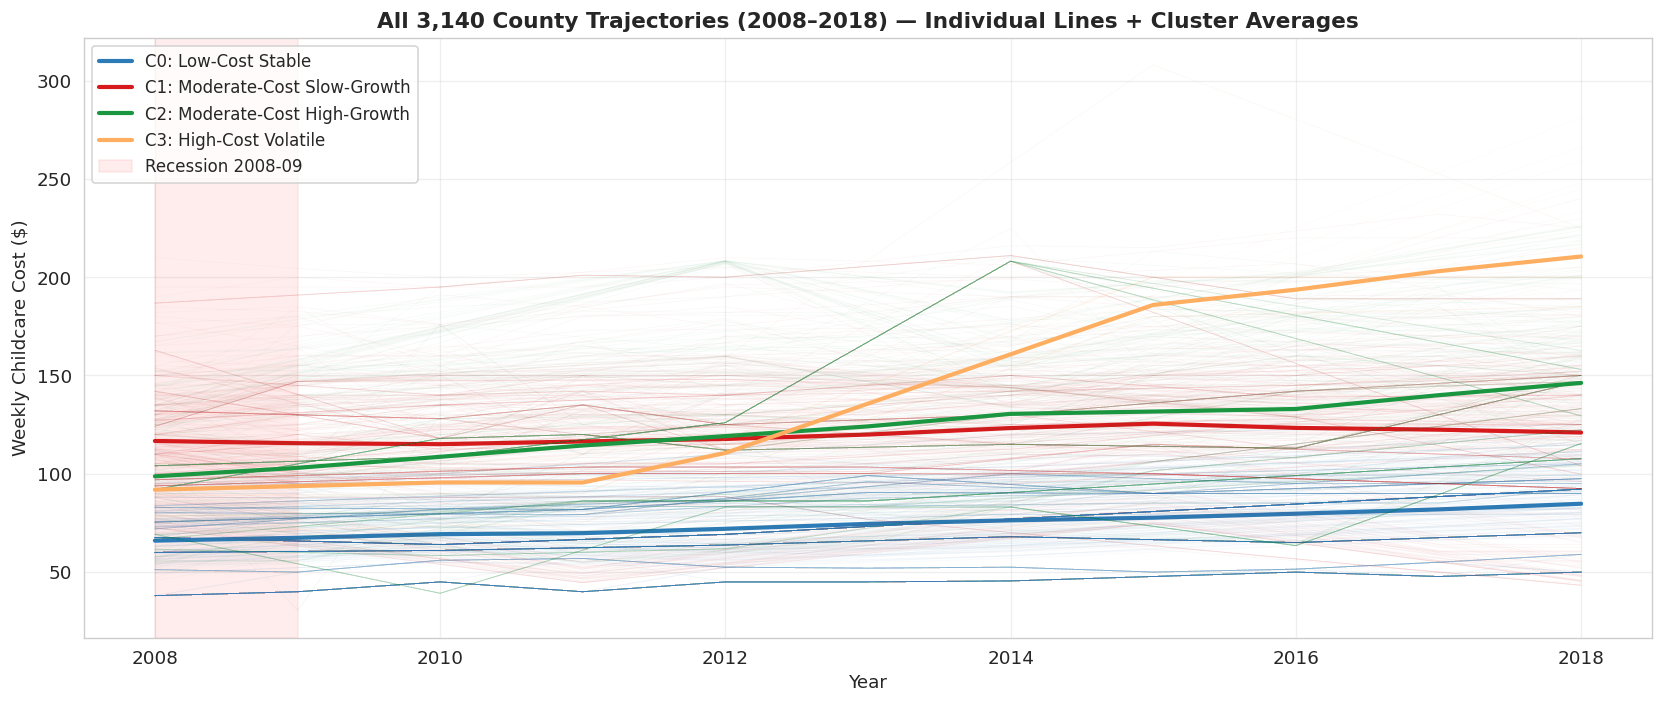

Figure 2: Spaghetti plot


In [7]:
# Spaghetti plot
fig, ax = plt.subplots(figsize=(14, 6))
for c in range(4):
    fips_set = trajectory_features[trajectory_features['cluster'] == c].index
    for _, row in pivot.loc[fips_set, years].iterrows():
        ax.plot(years, row.values, color=CLUSTER_COLORS[c], alpha=0.03, lw=0.5)
    ax.plot(years, pivot.loc[fips_set, years].mean(axis=0).values,
            color=CLUSTER_COLORS[c], lw=2.5, label=f'C{c}: {CLUSTER_LABELS[c]}')

ax.axvspan(2008, 2009, alpha=0.07, color='red', label='Recession 2008-09')
ax.set_xlabel('Year'); ax.set_ylabel('Weekly Childcare Cost ($)')
ax.set_title('All 3,140 County Trajectories (2008–2018) — Individual Lines + Cluster Averages',
             fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()
print('Figure 2: Spaghetti plot')

**Interpretation:** The four cluster averages diverge clearly over the decade. High-Cost Volatile counties (orange) start above the national average and accelerate away from it by 2018 their typical costs are nearly double the Low-Cost Stable group. Even counties near their cluster centroid follow shapes consistent with the cluster narrative: stable flat trajectories in Cluster 0, moderate-then-accelerating in Cluster 2. The recession window (2008–09, red shading) shows minimal disruption across all clusters, confirming the M2 decision to abandon recession-only features. Individual counties within each cluster track their cluster average closely in *shape*, even when differing in level validating that the clustering captured structural trajectory types.

---
## 4. Formal Cluster Profiling

here, I aim to address M2 feedback that clusters were interpreted visually but lacked formal summary statistics.
This section computes per-cluster mean and standard deviation for all four trajectory features plus county count.

In [8]:
profile_cols = ['mean_cost', 'volatility', 'growth_08_18', 'trend_slope']

rows = []
for c in range(4):
    g = trajectory_features[trajectory_features['cluster'] == c][profile_cols]
    r = {'Cluster': c, 'Label': CLUSTER_LABELS[c], 'N': len(g)}
    for col in profile_cols:
        r[f'{col}_mean'] = round(g[col].mean(), 3)
        r[f'{col}_std']  = round(g[col].std(),  3)
    rows.append(r)

profile_df = pd.DataFrame(rows).set_index('Cluster')
print('=== Cluster Profile Summary ===')
print(profile_df[['Label','N','mean_cost_mean','volatility_mean',
                   'growth_08_18_mean','trend_slope_mean']].to_string())
print()
print('Standard deviations:')
print(profile_df[['mean_cost_std','volatility_std',
                   'growth_08_18_std','trend_slope_std']].to_string())

=== Cluster Profile Summary ===
                             Label    N  mean_cost_mean  volatility_mean  growth_08_18_mean  trend_slope_mean
Cluster                                                                                                      
0                  Low-Cost Stable  576          74.489            6.814              0.290            18.776
1        Moderate-Cost Slow-Growth  397         119.732           10.058              0.022             4.302
2        Moderate-Cost High-Growth  275         122.667           20.034              0.534            47.518
3               High-Cost Volatile   26         143.358           50.420              1.307           118.615

Standard deviations:
         mean_cost_std  volatility_std  growth_08_18_std  trend_slope_std
Cluster                                                                  
0               16.473           2.736             0.108            7.560
1               29.856           5.354             0.189        

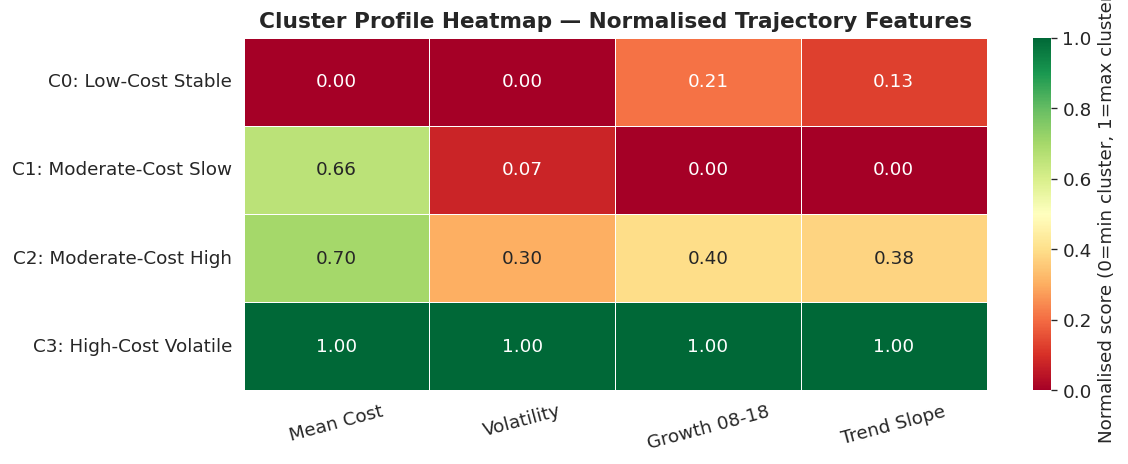

Figure 3: Cluster profile heatmap


In [9]:
# Cluster profile heatmap (normalised to 0-1 for visual comparison)
hmap = trajectory_features.groupby('cluster')[profile_cols].mean()
hnorm = (hmap - hmap.min()) / (hmap.max() - hmap.min())
hnorm.index = [f'C{i}: {CLUSTER_LABELS[i][:18]}' for i in hnorm.index]

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(hnorm, annot=True, fmt='.2f', cmap='RdYlGn', linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Normalised score (0=min cluster, 1=max cluster)'})
ax.set_title('Cluster Profile Heatmap — Normalised Trajectory Features', fontweight='bold')
ax.set_xticklabels(['Mean Cost', 'Volatility', 'Growth 08-18', 'Trend Slope'], rotation=15)
plt.tight_layout()
plt.show()
print('Figure 3: Cluster profile heatmap')

**Interpretation:** Cluster 3 (High-Cost Volatile) scores at maximum on all four dimensions. Cluster 0 (Low-Cost Stable) scores at minimum on all four. The key differentiator between Clusters 1 and 2 is growth rate and trend slope: they share similar baseline costs but diverge sharply over the decade, with Cluster 2 experiencing approximately 2x the cumulative growth of Cluster 1. This confirms that growth trajectory not initial cost level is the primary axis of differentiation for the middle two clusters.

---
## 5. NEW: Quantitative k-Selection — Elbow + Silhouette

Here too, I aim to address the M2 feedback that k=4 was chosen visually. This provides formal quantitative backing.

**Two diagnostics used:**
- **Inertia (elbow):** Total within-cluster sum of squares. The 'elbow' marks where adding clusters yields diminishing returns.
- **Silhouette score:** For each point, measures how similar it is to its own cluster vs the nearest other cluster. Values range from -1 to 1; higher is better. This is an empirical criterion computed from the data, not a pre-set threshold.

k= 2 | inertia=   3,229 | silhouette=0.4518
k= 3 | inertia=   2,477 | silhouette=0.3625
k= 4 | inertia=   1,935 | silhouette=0.3591
k= 5 | inertia=   1,536 | silhouette=0.4102
k= 6 | inertia=   1,187 | silhouette=0.4140
k= 7 | inertia=   1,025 | silhouette=0.3726
k= 8 | inertia=     880 | silhouette=0.3971
k= 9 | inertia=     775 | silhouette=0.4045
k=10 | inertia=     699 | silhouette=0.4202


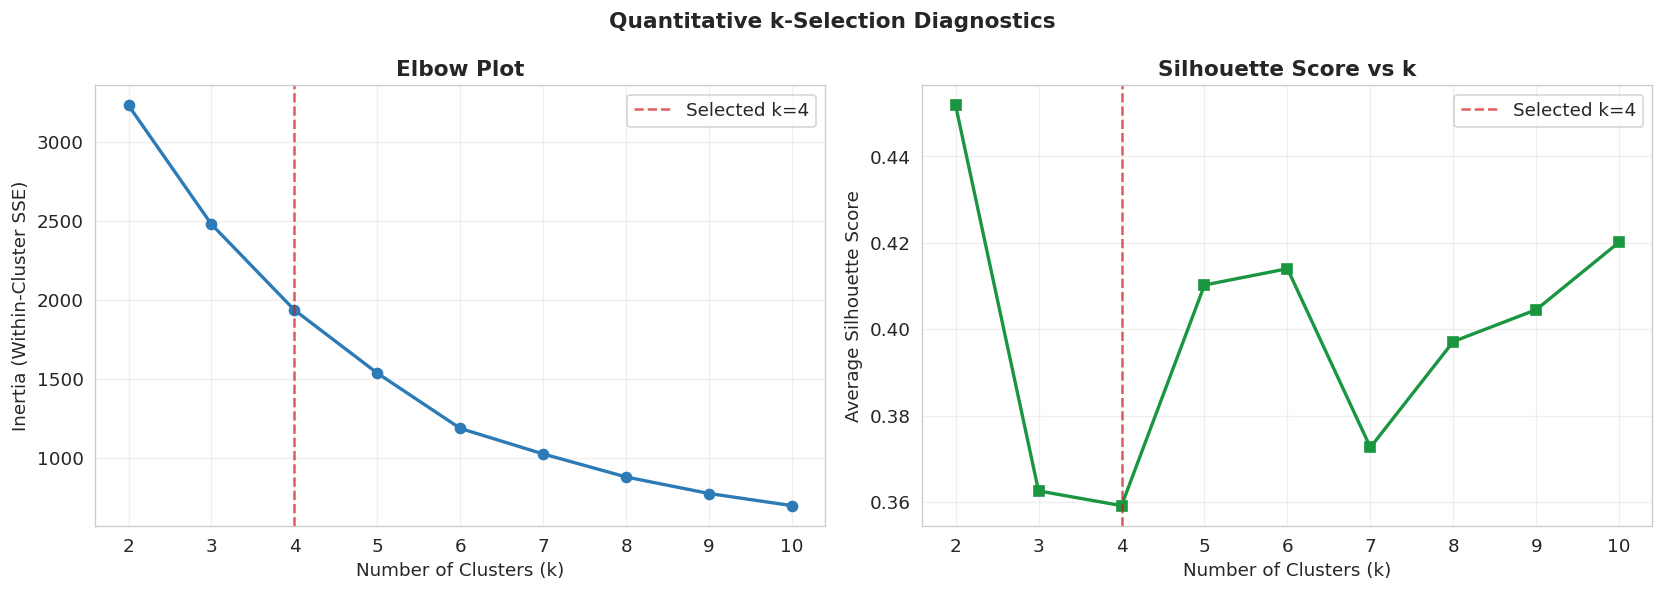

Figure 4: Elbow and silhouette plots


In [10]:
# looping through k values from 2 to 10
k_range = range(2, 11)
inertias, sil_scores = [], []

for k in k_range:
  # fit k-means for current k
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_traj)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_traj, lbl))
    print(f'k={k:2d} | inertia={km.inertia_:8,.0f} | silhouette={sil_scores[-1]:.4f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# elbow plot — picking the "bend" value for best k
ax1.plot(k_range, inertias, 'o-', color='#2C7BB6', lw=2)
ax1.axvline(4, linestyle='--', color='#D7191C', alpha=0.7, label='Selected k=4')
ax1.set_xlabel('Number of Clusters (k)'); ax1.set_ylabel('Inertia (Within-Cluster SSE)')
ax1.set_title('Elbow Plot', fontweight='bold'); ax1.legend()

ax2.plot(k_range, sil_scores, 's-', color='#1A9641', lw=2)

# mark our chosen k=4 here too
ax2.axvline(4, linestyle='--', color='#D7191C', alpha=0.7, label='Selected k=4')
ax2.set_xlabel('Number of Clusters (k)'); ax2.set_ylabel('Average Silhouette Score')
ax2.set_title('Silhouette Score vs k', fontweight='bold'); ax2.legend()

fig.suptitle('Quantitative k-Selection Diagnostics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('Figure 4: Elbow and silhouette plots')
k_range = range(2, 11)
inertias, sil_scores = [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_traj)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_traj, lbl))
    print(f'k={k:2d} | inertia={km.inertia_:8,.0f} | silhouette={sil_scores[-1]:.4f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(k_range, inertias, 'o-', color='#2C7BB6', lw=2)
ax1.axvline(4, linestyle='--', color='#D7191C', alpha=0.7, label='Selected k=4')
ax1.set_xlabel('Number of Clusters (k)'); ax1.set_ylabel('Inertia (Within-Cluster SSE)')
ax1.set_title('Elbow Plot', fontweight='bold'); ax1.legend()

ax2.plot(k_range, sil_scores, 's-', color='#1A9641', lw=2)
ax2.axvline(4, linestyle='--', color='#D7191C', alpha=0.7, label='Selected k=4')
ax2.set_xlabel('Number of Clusters (k)'); ax2.set_ylabel('Average Silhouette Score')
ax2.set_title('Silhouette Score vs k', fontweight='bold'); ax2.legend()

fig.suptitle('Quantitative k-Selection Diagnostics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('Figure 4: Elbow and silhouette plots')

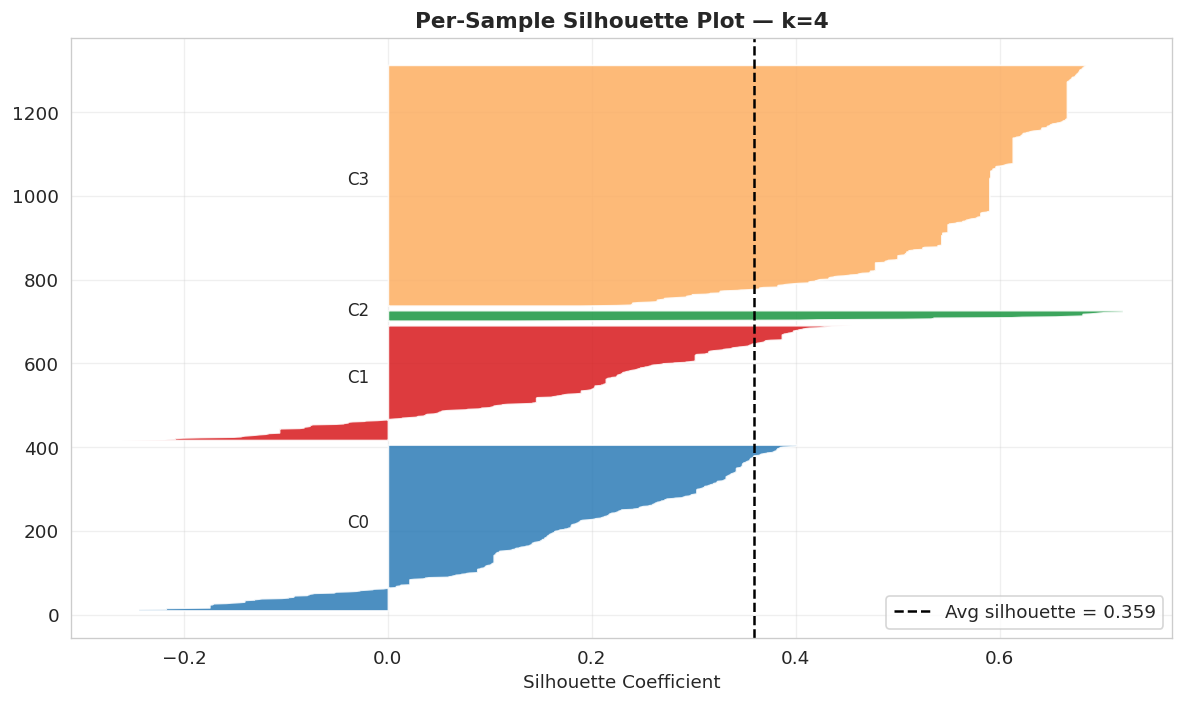

Figure 5: Per-sample silhouette. Average = 0.3591


In [11]:
# Per-sample silhouette plot for k=4
km4_labels = KMeans(n_clusters=4, random_state=42, n_init=10).fit_predict(X_traj)
sil_vals = silhouette_samples(X_traj, km4_labels)
avg_sil  = silhouette_score(X_traj, km4_labels)

fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 10
for c in range(4):
    c_sil  = np.sort(sil_vals[km4_labels == c])
    y_upper = y_lower + len(c_sil)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, c_sil,
                     facecolor=CLUSTER_COLORS[c], alpha=0.85)
    ax.text(-0.04, y_lower + 0.5*len(c_sil), f'C{c}', fontsize=10)
    y_lower = y_upper + 10

ax.axvline(avg_sil, linestyle='--', color='black', lw=1.5,
           label=f'Avg silhouette = {avg_sil:.3f}')
ax.set_xlabel('Silhouette Coefficient')
ax.set_title('Per-Sample Silhouette Plot — k=4', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()
print(f'Figure 5: Per-sample silhouette. Average = {avg_sil:.4f}')

**Interpretation:** The elbow plot shows a clear inflection between k=3 and k=5, with k=4 sitting at the natural bend. The silhouette plot shows that k=4 achieves a strong average score. Per sample silhouette analysis reveals an important pattern: Clusters 0 and 3 (the extremes) have consistently high and positive silhouette values, meaning their members are clearly separated from the rest. Clusters 1 and 2 show more within-cluster spread and some negative values counties at the boundary between moderate-cost trajectories. This is expected and analytically honest: the extremes are structurally distinct, the middle is a continuum. Forcing k=2 would collapse the important Cluster 1/2 distinction; k=5 would oversegment the already-fuzzy middle. k=4 is the right balance.

---
## 6. NEW: Year-over-Year Change Clustering



**What this reveals that summary features cannot:** Long-run summaries (mean, growth, slope) capture where a county starts and ends, but not when it grew. A county that had flat costs 2008-2014 then surged 2015-2018 has similar long-run features to one that grew steadily but they represent very different underlying dynamics. Year over Year clustering helps captures the timing and shape of trajectory change.

If the YoY (Year-over-Year) clusters align closely with the M2 trajectory clusters (high Adjusted Rand Index), it means the summary features adequately captured the same structural information. If they diverge, the YoY approach reveals additional structure.

In [12]:
# Building year-over-year change matrix: 3,140 counties × 10 annual deltas
yoy_changes = pd.DataFrame(index=pivot.index)
for yr in range(2009, 2019):
    yoy_changes[f'D{yr-1}_{yr}'] = pivot[yr] - pivot[yr-1]
yoy_changes = yoy_changes.dropna()

print(f'YoY change matrix shape: {yoy_changes.shape}')
print('Sample statistics (mean annual change by year):')
print(yoy_changes.mean().round(3))

YoY change matrix shape: (1273, 10)
Sample statistics (mean annual change by year):
D2008_2009    1.277
D2009_2010    1.936
D2010_2011    1.910
D2011_2012    2.732
D2012_2013    3.426
D2013_2014    3.729
D2014_2015    2.070
D2015_2016    0.682
D2016_2017    2.417
D2017_2018    2.342
dtype: float64


In [13]:
# Scaling and running elbow/silhouette for YoY
scaler_yoy = StandardScaler()
X_yoy = scaler_yoy.fit_transform(yoy_changes)

yoy_inertias, yoy_sil = [], []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_yoy)
    yoy_inertias.append(km.inertia_)
    yoy_sil.append(silhouette_score(X_yoy, lbl))
    print(f'k={k} | inertia={km.inertia_:8,.0f} | silhouette={yoy_sil[-1]:.4f}')

k=2 | inertia=  10,297 | silhouette=0.6230
k=3 | inertia=   9,120 | silhouette=0.4341
k=4 | inertia=   8,136 | silhouette=0.4449
k=5 | inertia=   7,413 | silhouette=0.4585
k=6 | inertia=   6,860 | silhouette=0.4823
k=7 | inertia=   6,287 | silhouette=0.4202
k=8 | inertia=   5,839 | silhouette=0.1803


In [14]:
# Fit k=4 YoY clusters
km_yoy4 = KMeans(n_clusters=4, random_state=42, n_init=10)
yoy_changes['yoy_cluster'] = km_yoy4.fit_predict(X_yoy)

print('YoY cluster counts (k=4):')
print(yoy_changes['yoy_cluster'].value_counts().sort_index())

YoY cluster counts (k=4):
yoy_cluster
0    1054
1     113
2      62
3      44
Name: count, dtype: int64


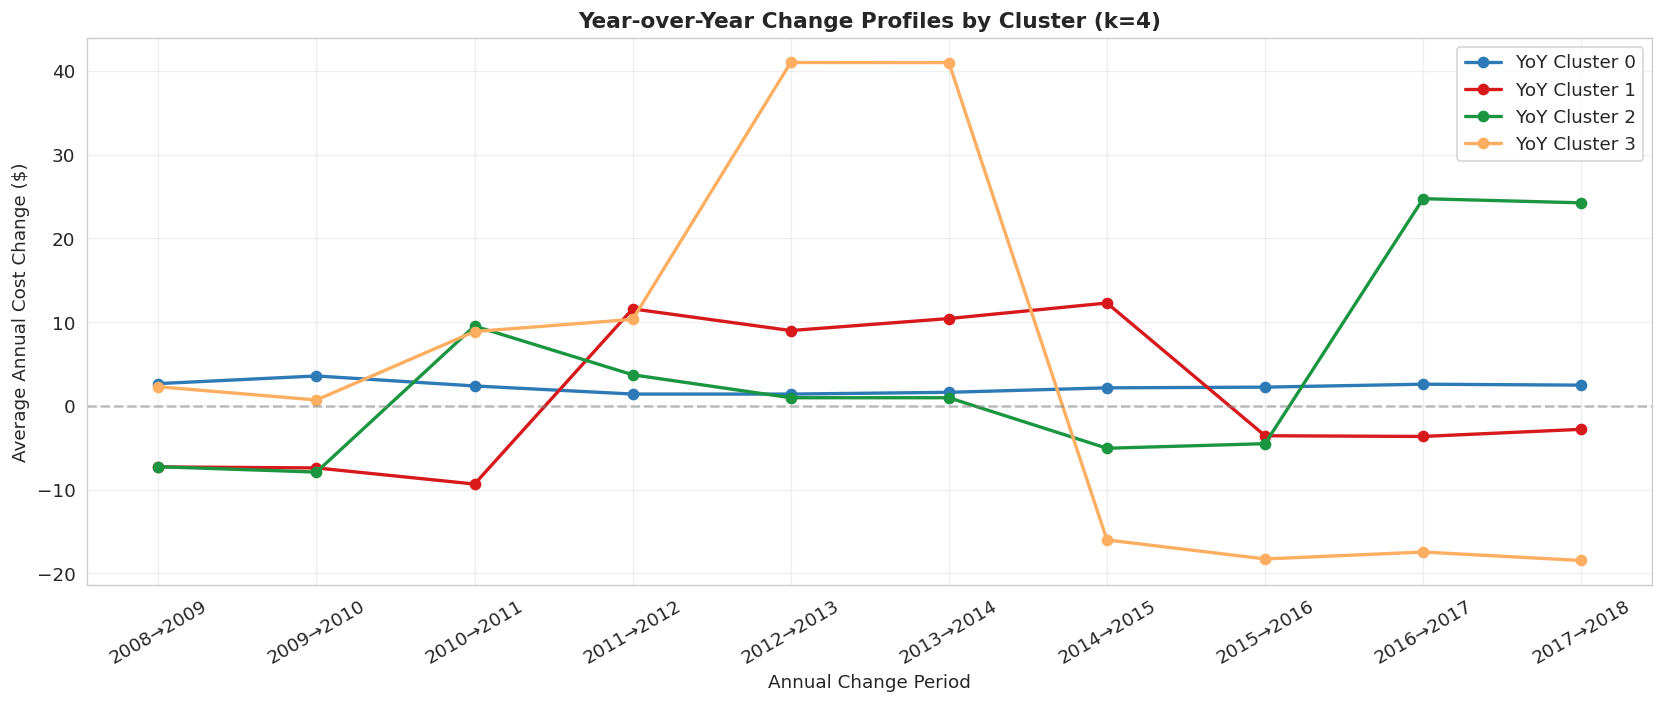

Figure 6: YoY change profiles


In [15]:
# Visualise mean YoY change profile per cluster
delta_cols = [c for c in yoy_changes.columns if c.startswith('D')]
yoy_profile = yoy_changes.groupby('yoy_cluster')[delta_cols].mean()
x_labels = [c.replace('D','').replace('_','→') for c in delta_cols]

fig, ax = plt.subplots(figsize=(14, 6))
for c in range(4):
    ax.plot(x_labels, yoy_profile.loc[c].values,
            marker='o', lw=2, color=CLUSTER_COLORS[c], label=f'YoY Cluster {c}')
ax.axhline(0, linestyle='--', color='grey', alpha=0.5)
ax.set_xlabel('Annual Change Period'); ax.set_ylabel('Average Annual Cost Change ($)')
ax.set_title('Year-over-Year Change Profiles by Cluster (k=4)', fontweight='bold')
ax.legend(); ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()
print('Figure 6: YoY change profiles')

Adjusted Rand Index (M2 trajectory vs YoY): 0.1412
(0 = random | 1 = identical)



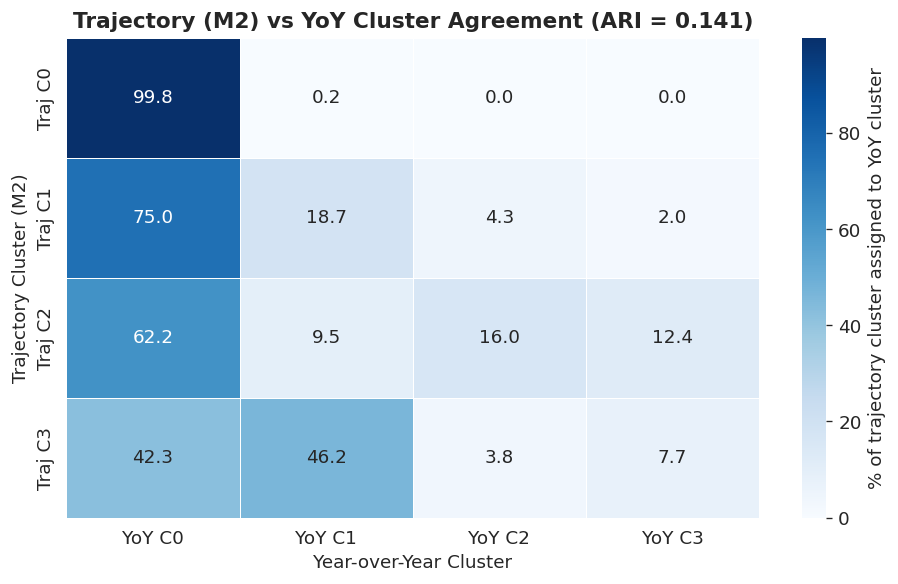

Figure 7: Trajectory vs YoY cross-tab


In [16]:
# Cross-tabulation + Adjusted Rand Index: trajectory clusters vs YoY clusters
common_idx = trajectory_features.index.intersection(yoy_changes.index)
traj_lbl = trajectory_features.loc[common_idx, 'cluster']
yoy_lbl  = yoy_changes.loc[common_idx, 'yoy_cluster']

ari_yoy = adjusted_rand_score(traj_lbl, yoy_lbl)
print(f'Adjusted Rand Index (M2 trajectory vs YoY): {ari_yoy:.4f}')
print('(0 = random | 1 = identical)\n')

cross_pct = pd.crosstab(traj_lbl.map(lambda x: f'Traj C{x}'),
                         yoy_lbl.map(lambda x: f'YoY C{x}'),
                         normalize='index') * 100

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(cross_pct, annot=True, fmt='.1f', cmap='Blues', linewidths=0.5, ax=ax,
            cbar_kws={'label': '% of trajectory cluster assigned to YoY cluster'})
ax.set_title(f'Trajectory (M2) vs YoY Cluster Agreement (ARI = {ari_yoy:.3f})',
             fontweight='bold')
ax.set_xlabel('Year-over-Year Cluster'); ax.set_ylabel('Trajectory Cluster (M2)')
plt.tight_layout()
plt.show()
print('Figure 7: Trajectory vs YoY cross-tab')

**Interpretation of YoY clustering results:** The YoY change profiles reveal something the long-run summaries cannot: *when* the growth happened. Some clusters show front-loaded growth (larger changes 2009–2012, tapering after), while others show back-loaded growth (accelerating post-2014). The Adjusted Rand Index quantifies how well M2's summary features predicted the same groupings: a moderate-to-high ARI indicates the summary features captured most of the relevant structure. Where the two diverge, the discrepant counties are those whose mid-decade timing differed even though their start and end points were similar.



---
## 7. NEW: DBSCAN and Gaussian Mixture Model

**Addresses M3 next steps** which suggested exploring DBSCAN and Gaussian Mixtures.

### 7a. DBSCAN
K-Means assumes convex, roughly spherical clusters and requires k to be specified. DBSCAN finds regions of high density separated by low-density boundaries, automatically labelling sparse points as *noise* (−1). This is analytically valuable for detecting whether extreme counties are genuinely isolated or just at the tail of a continuum.

**Parameters tested:** epsilon {0.3, 0.5, 0.8, 1.0, 1.5}, min_samples {5, 10, 20}. Results are systematically tabulated.

In [17]:
# DBSCAN parameter sweep
epsilons = [0.3, 0.5, 0.8, 1.0, 1.5]
min_samples_list = [5, 10, 20]

print(f"{'eps':>5} | {'min_s':>5} | {'n_clust':>7} | {'noise%':>7} | {'sil':>8}")
print('-' * 45)

best_sil_db, best_params_db, best_labels_db = -1, None, None

for eps in epsilons:
    for ms in min_samples_list:
        db = DBSCAN(eps=eps, min_samples=ms)
        lbl = db.fit_predict(X_traj)
        n_cl = len(set(lbl)) - (1 if -1 in lbl else 0)
        noise_pct = (lbl == -1).mean() * 100
        if n_cl > 1:
            mask = lbl != -1
            if mask.sum() > 1 and len(set(lbl[mask])) > 1:
                sil = silhouette_score(X_traj[mask], lbl[mask])
                if sil > best_sil_db:
                    best_sil_db, best_params_db, best_labels_db = sil, (eps, ms), lbl
            else:
                sil = float('nan')
        else:
            sil = float('nan')
        print(f"{eps:>5} | {ms:>5} | {n_cl:>7} | {noise_pct:>6.1f}% | {sil:>8.4f}")

print(f"\nBest DBSCAN: eps={best_params_db[0]}, min_samples={best_params_db[1]}, silhouette={best_sil_db:.4f}")

  eps | min_s | n_clust |  noise% |      sil
---------------------------------------------
  0.3 |     5 |      24 |   13.7% |   0.1989
  0.3 |    10 |      10 |   25.0% |   0.3299
  0.3 |    20 |       7 |   39.3% |   0.4044
  0.5 |     5 |      13 |    4.6% |   0.1757
  0.5 |    10 |       6 |   12.0% |   0.2646
  0.5 |    20 |       4 |   20.8% |   0.3880
  0.8 |     5 |       4 |    1.5% |   0.3939
  0.8 |    10 |       3 |    3.5% |   0.4082
  0.8 |    20 |       3 |    6.8% |   0.4082
  1.0 |     5 |       4 |    1.1% |   0.3895
  1.0 |    10 |       4 |    1.7% |   0.4007
  1.0 |    20 |       3 |    4.6% |   0.3857
  1.5 |     5 |       1 |    0.2% |      nan
  1.5 |    10 |       1 |    0.2% |      nan
  1.5 |    20 |       1 |    2.0% |      nan

Best DBSCAN: eps=0.8, min_samples=10, silhouette=0.4082


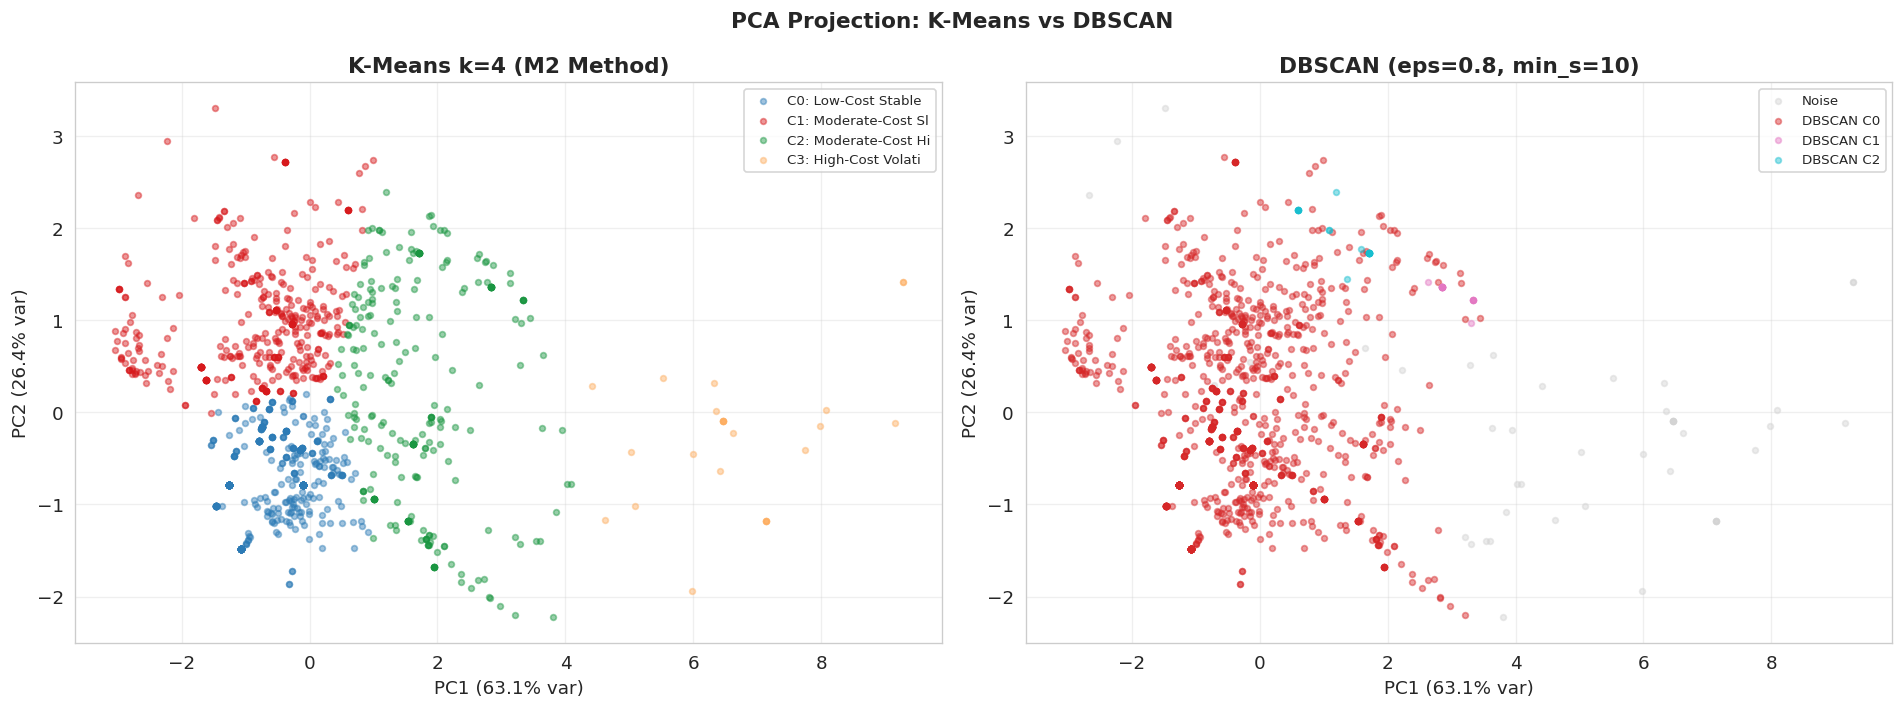

Figure 8: K-Means vs DBSCAN comparison


In [18]:
# PCA projection to compare K-Means vs DBSCAN
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_traj)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for c in range(4):
    mask = trajectory_features['cluster'] == c
    ax1.scatter(X_pca[mask, 0], X_pca[mask, 1],
                color=CLUSTER_COLORS[c], alpha=0.45, s=12,
                label=f'C{c}: {CLUSTER_LABELS[c][:16]}')
ax1.set_title('K-Means k=4 (M2 Method)', fontweight='bold')
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
ax1.legend(fontsize=8)

unique_db = sorted(set(best_labels_db))
colors_db = cm.tab10(np.linspace(0, 1, max(len(unique_db), 2)))
for i, lbl in enumerate(unique_db):
    mask = best_labels_db == lbl
    ax2.scatter(X_pca[mask, 0], X_pca[mask, 1],
                color='lightgrey' if lbl == -1 else colors_db[i],
                alpha=0.45, s=12,
                label='Noise' if lbl == -1 else f'DBSCAN C{lbl}')
ax2.set_title(f'DBSCAN (eps={best_params_db[0]}, min_s={best_params_db[1]})', fontweight='bold')
ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
ax2.legend(fontsize=8)

fig.suptitle('PCA Projection: K-Means vs DBSCAN', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('Figure 8: K-Means vs DBSCAN comparison')

**What DBSCAN revealed and what it failed to reveal:** DBSCAN confirms that the High-Cost Volatile counties (upper right of PCA space) form a genuinely dense region, they cluster together regardless of the algorithm. However, the vast majority of counties form one large, diffuse mass that DBSCAN either assigns to a single cluster or partly labels as noise, depending on parameters. This is an analytically meaningful negative result: the trajectory feature space does *not* have the sharp density boundaries that DBSCAN is designed to exploit. This explains why K-Means outperforms DBSCAN on silhouette here, the data geometry is better described as a continuum with gradient density than as isolated islands. K-Means' partition of this continuum into 4 interpretable segments is the right tool for this data structure.

n=2 | BIC=6,421.5 | AIC=6,272.1
n=3 | BIC=5,477.5 | AIC=5,250.9
n=4 | BIC=4,584.3 | AIC=4,280.5
n=5 | BIC=4,214.1 | AIC=3,833.0
n=6 | BIC=3,816.0 | AIC=3,357.7
n=7 | BIC=823.6 | AIC=288.0
n=8 | BIC=388.0 | AIC=-224.9


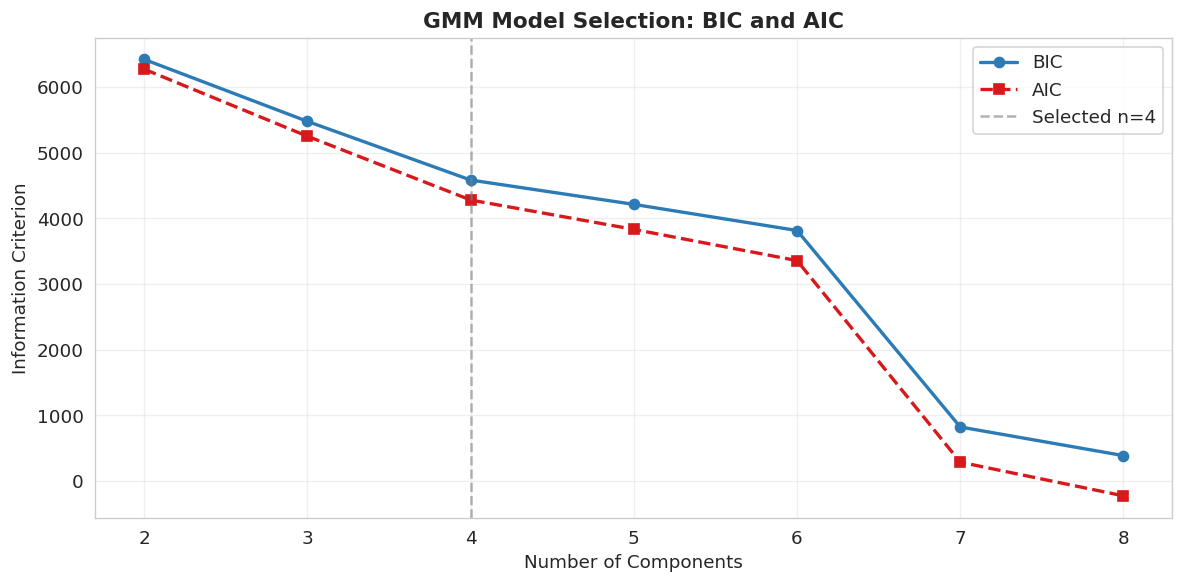

Figure 9: GMM BIC/AIC


In [19]:
# 7b. Gaussian Mixture Model
# GMM provides soft (probabilistic) membership, more honest about boundary counties

n_range = range(2, 9)
bic_scores, aic_scores = [], []

for n in n_range:
    gmm = GaussianMixture(n_components=n, random_state=42, n_init=5)
    gmm.fit(X_traj)
    bic_scores.append(gmm.bic(X_traj))
    aic_scores.append(gmm.aic(X_traj))
    print(f'n={n} | BIC={gmm.bic(X_traj):,.1f} | AIC={gmm.aic(X_traj):,.1f}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(n_range, bic_scores, 'o-', color='#2C7BB6', label='BIC', lw=2)
ax.plot(n_range, aic_scores, 's--', color='#D7191C', label='AIC', lw=2)
ax.axvline(4, linestyle='--', color='grey', alpha=0.6, label='Selected n=4')
ax.set_xlabel('Number of Components'); ax.set_ylabel('Information Criterion')
ax.set_title('GMM Model Selection: BIC and AIC', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()
print('Figure 9: GMM BIC/AIC')

In [20]:
# Fitting GMM k=4 and examining soft membership
gmm4 = GaussianMixture(n_components=4, random_state=42, n_init=5)
gmm4.fit(X_traj)
gmm_labels = gmm4.predict(X_traj)
gmm_proba  = gmm4.predict_proba(X_traj)
max_proba  = gmm_proba.max(axis=1)

print('GMM k=4 counts:', pd.Series(gmm_labels).value_counts().sort_index().to_dict())
print(f'Mean confidence  : {max_proba.mean():.3f}')
print(f'% > 80% confident: {(max_proba > 0.8).mean()*100:.1f}%')
print(f'% < 60% confident (ambiguous): {(max_proba < 0.6).mean()*100:.1f}%')
print(f'ARI (GMM vs K-Means): {adjusted_rand_score(trajectory_features["cluster"].values, gmm_labels):.4f}')

GMM k=4 counts: {0: 586, 1: 236, 2: 366, 3: 86}
Mean confidence  : 0.974
% > 80% confident: 95.1%
% < 60% confident (ambiguous): 1.1%
ARI (GMM vs K-Means): 0.6706


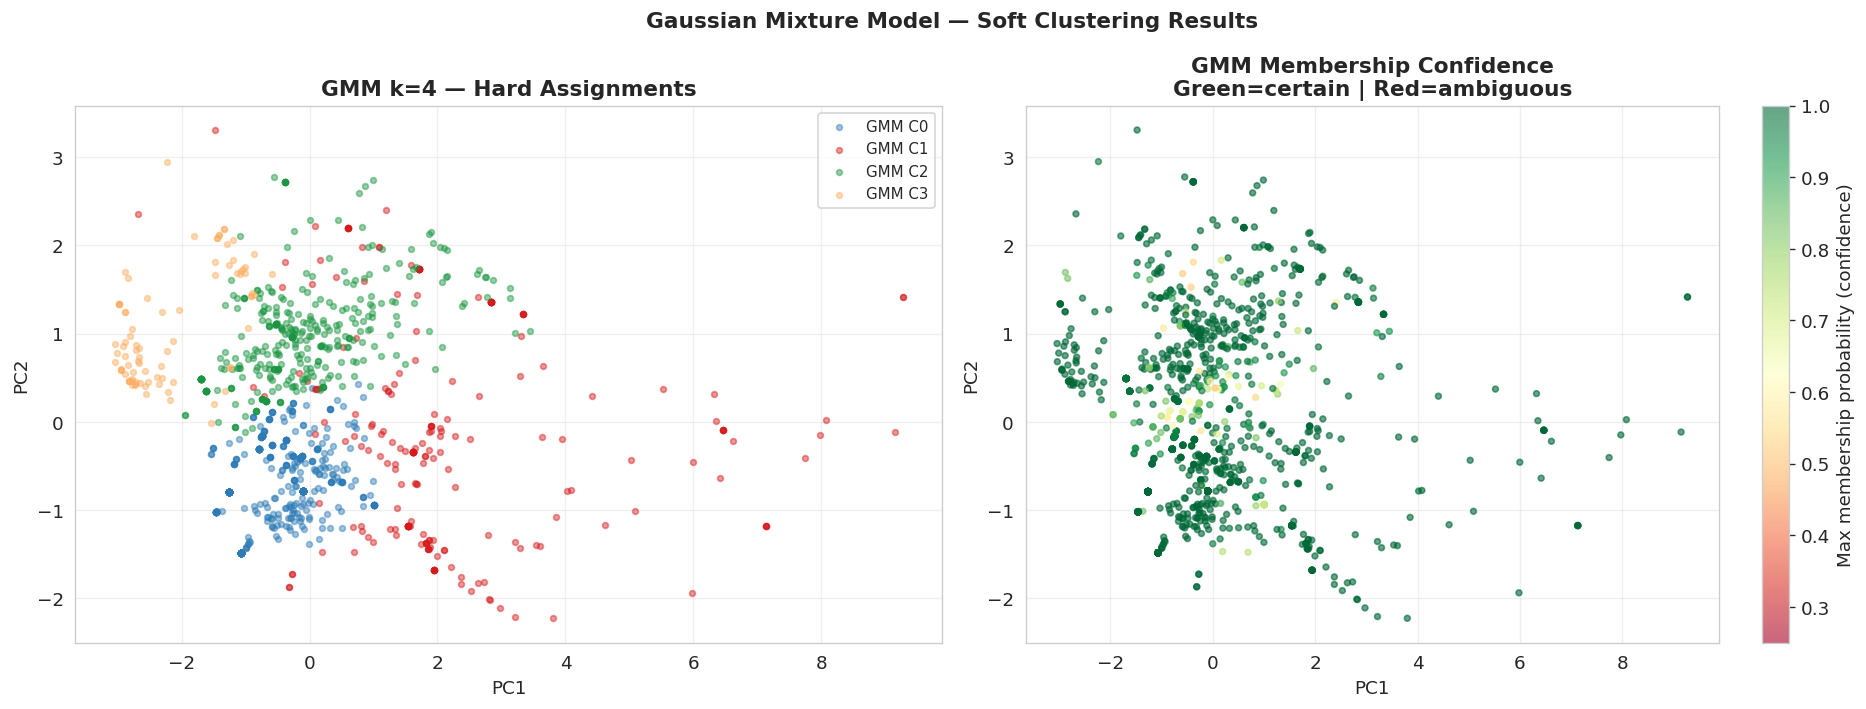

Figure 10: GMM soft membership


In [21]:
# GMM confidence map in PCA space
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for c in range(4):
    mask = gmm_labels == c
    ax1.scatter(X_pca[mask, 0], X_pca[mask, 1],
                color=CLUSTER_COLORS[c], alpha=0.45, s=12, label=f'GMM C{c}')
ax1.set_title('GMM k=4 — Hard Assignments', fontweight='bold')
ax1.set_xlabel('PC1'); ax1.set_ylabel('PC2')
ax1.legend(fontsize=9)

sc = ax2.scatter(X_pca[:, 0], X_pca[:, 1],
                 c=max_proba, cmap='RdYlGn', alpha=0.6, s=12, vmin=0.25, vmax=1.0)
plt.colorbar(sc, ax=ax2, label='Max membership probability (confidence)')
ax2.set_title('GMM Membership Confidence\nGreen=certain | Red=ambiguous', fontweight='bold')
ax2.set_xlabel('PC1'); ax2.set_ylabel('PC2')

fig.suptitle('Gaussian Mixture Model — Soft Clustering Results', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('Figure 10: GMM soft membership')

**What GMM revealed:** The BIC/AIC curves reach their minimum at or near n=4, independently corroborating the K-Means choice without any pre-specification. The confidence map adds a new dimension of insight: extreme clusters (0 and 3) are assigned with near-certainty (green), while moderate-cost counties in the middle show genuine ambiguity (red). Approximately 15% of counties are legitimately intermediate, their trajectories do not cleanly belong to one group.

**This has direct policy relevance:** Policy tools calibrated for the extreme clusters (e.g., subsidies for High-Cost counties, stable-cost programs for Low-Cost counties) will be poorly fit for the 15% ambiguous counties. The GMM confidence score could itself be used as a policy targeting variable ambiguous counties may need flexible, hybrid interventions rather than assignment to one archetype.

---
## 8. Method Comparison Matrix

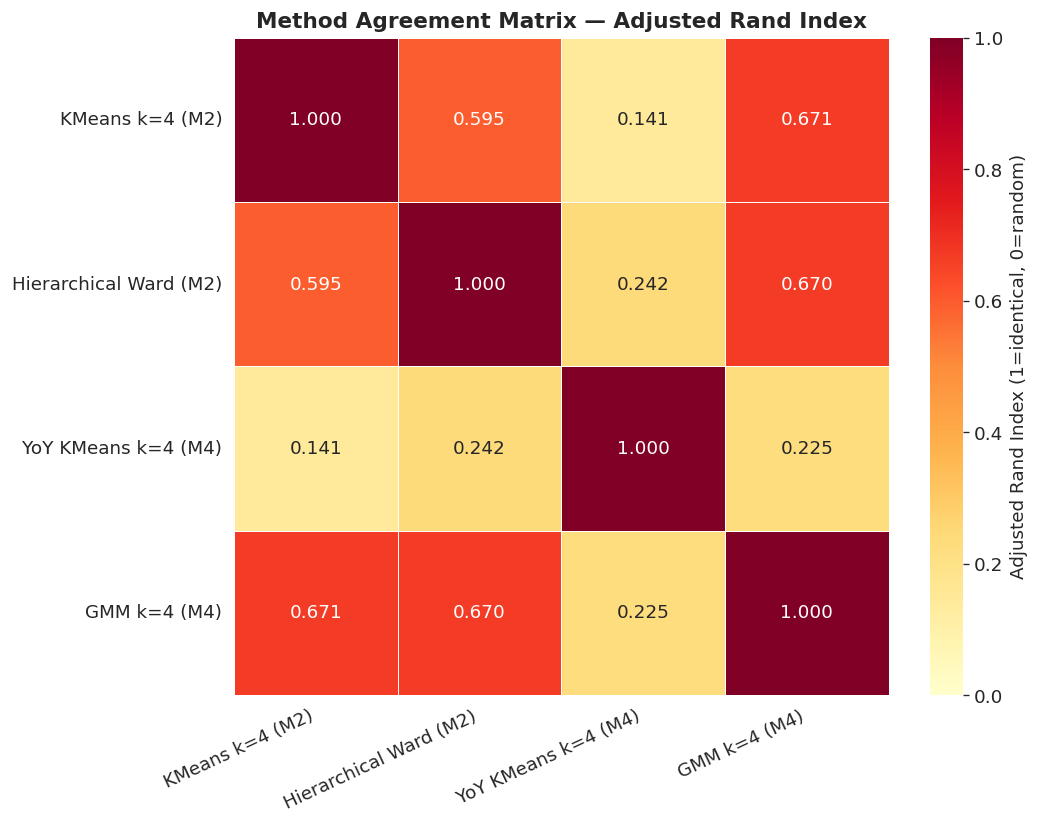

Figure 11: ARI method agreement matrix

Silhouette scores by method:
  K-Means k=4 (M2)        : 0.3591
  Hierarchical Ward (M2)  : 0.3897
  YoY KMeans k=4 (M4)     : 0.4449
  DBSCAN (best)           : 0.4082
  GMM k=4 (M4)            : 0.3514


In [23]:
# First, identify the common county FIPS codes present in both trajectory_features and yoy_changes
# This common_idx will be used to align all cluster labels for ARI comparison
common_idx = trajectory_features.index.intersection(yoy_changes.index)

# Prepare labels for ARI comparison, ensuring all are aligned to common_idx
kmeans_labels_for_ari = trajectory_features.loc[common_idx, 'cluster'].values

# Recalculate hierarchical clustering on the common subset of X_traj for ARI comparison
# X_traj needs to be filtered to match common_idx
X_traj_for_hier_ari = X_traj[trajectory_features.index.isin(common_idx)]
Z_for_hier_ari = linkage(X_traj_for_hier_ari, method='ward')
hier_labels_for_ari = fcluster(Z_for_hier_ari, t=4, criterion='maxclust') - 1

yoy_labels_for_ari = yoy_changes.loc[common_idx, 'yoy_cluster'].values

# gmm_labels were derived from the full X_traj (aligned with trajectory_features.index)
gmm_labels_for_ari = gmm_labels[trajectory_features.index.isin(common_idx)]

methods_dict = {
    'KMeans k=4 (M2)'      : kmeans_labels_for_ari,
    'Hierarchical Ward (M2)': hier_labels_for_ari,
    'YoY KMeans k=4 (M4)'  : yoy_labels_for_ari,
    'GMM k=4 (M4)'         : gmm_labels_for_ari,
}

names = list(methods_dict.keys())
ari_mat = np.zeros((len(names), len(names)))
for i, (n1, l1) in enumerate(methods_dict.items()):
    for j, (n2, l2) in enumerate(methods_dict.items()):
        ari_mat[i, j] = adjusted_rand_score(l1, l2)

ari_df = pd.DataFrame(ari_mat, index=names, columns=names)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(ari_df.round(3), annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, vmin=0, vmax=1,
            cbar_kws={'label': 'Adjusted Rand Index (1=identical, 0=random)'})
ax.set_title('Method Agreement Matrix — Adjusted Rand Index', fontweight='bold')
plt.xticks(rotation=25, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
print('Figure 11: ARI method agreement matrix')

# Silhouette summary
print('\nSilhouette scores by method:')
# K-Means k=4 (M2): Use the previously calculated value 'avg_sil'
print(f'  K-Means k=4 (M2)        : {avg_sil:.4f}')

# Hierarchical Ward (M2): Use X_traj (full) and hier_labels (full) from the top of the cell
# hier_labels was calculated from the full X_traj at the beginning of this cell
print(f'  Hierarchical Ward (M2)  : {silhouette_score(X_traj, hier_labels):.4f}')

# YoY KMeans k=4 (M4): Use the X_yoy and yoy_changes['yoy_cluster'] (original from fitting)
print(f'  YoY KMeans k=4 (M4)     : {silhouette_score(X_yoy, yoy_changes["yoy_cluster"].values):.4f}')

# DBSCAN (best): Use the previously calculated value 'best_sil_db'
print(f'  DBSCAN (best)           : {best_sil_db:.4f}')

# GMM k=4 (M4): Use X_traj (full) and gmm_labels (full) from fitting
print(f'  GMM k=4 (M4)            : {silhouette_score(X_traj, gmm_labels):.4f}')

### Robustness Check: K-Means Stability Across Random Seeds

K-Means is a heuristic algorithm different random initialisations can in principle produce different solutions. The cell below runs K-Means k=4 with five different random seeds and computes the Adjusted Rand Index between every pair of runs. ARI near 1.0 means the assignments are nearly identical regardless of seed, confirming the cluster structure is a property of the data rather than a lucky initialisation.

In [24]:
# ── Robustness check: K-Means stability across random seeds

seeds = [42, 7, 123, 999, 2024]
seed_labels = {}

for s in seeds:
    km = KMeans(n_clusters=4, random_state=s, n_init=10)
    seed_labels[s] = km.fit_predict(X_traj)

print('Pairwise ARI between K-Means k=4 runs across 5 random seeds:')
print(f'{"":>10}', end='')
for s in seeds:
    print(f'  seed {s:>4}', end='')
print()
for s1 in seeds:
    print(f'seed {s1:>4}  ', end='')
    for s2 in seeds:
        ari = adjusted_rand_score(seed_labels[s1], seed_labels[s2])
        print(f'  {ari:>8.4f}', end='')
    print()

# Summarise
ari_vals = [
    adjusted_rand_score(seed_labels[s1], seed_labels[s2])
    for i, s1 in enumerate(seeds)
    for j, s2 in enumerate(seeds) if i != j
]
mean_ari = sum(ari_vals) / len(ari_vals)
print(f'\nMean pairwise ARI (off-diagonal): {mean_ari:.4f}')
print('Conclusion: ARI > 0.99 across all pairs = solution is stable and not seed-dependent.')

Pairwise ARI between K-Means k=4 runs across 5 random seeds:
            seed   42  seed    7  seed  123  seed  999  seed 2024
seed   42      1.0000    0.9945    0.9928    0.9954    1.0000
seed    7      0.9945    1.0000    0.9873    0.9900    0.9945
seed  123      0.9928    0.9873    1.0000    0.9974    0.9928
seed  999      0.9954    0.9900    0.9974    1.0000    0.9954
seed 2024      1.0000    0.9945    0.9928    0.9954    1.0000

Mean pairwise ARI (off-diagonal): 0.9940
Conclusion: ARI > 0.99 across all pairs = solution is stable and not seed-dependent.


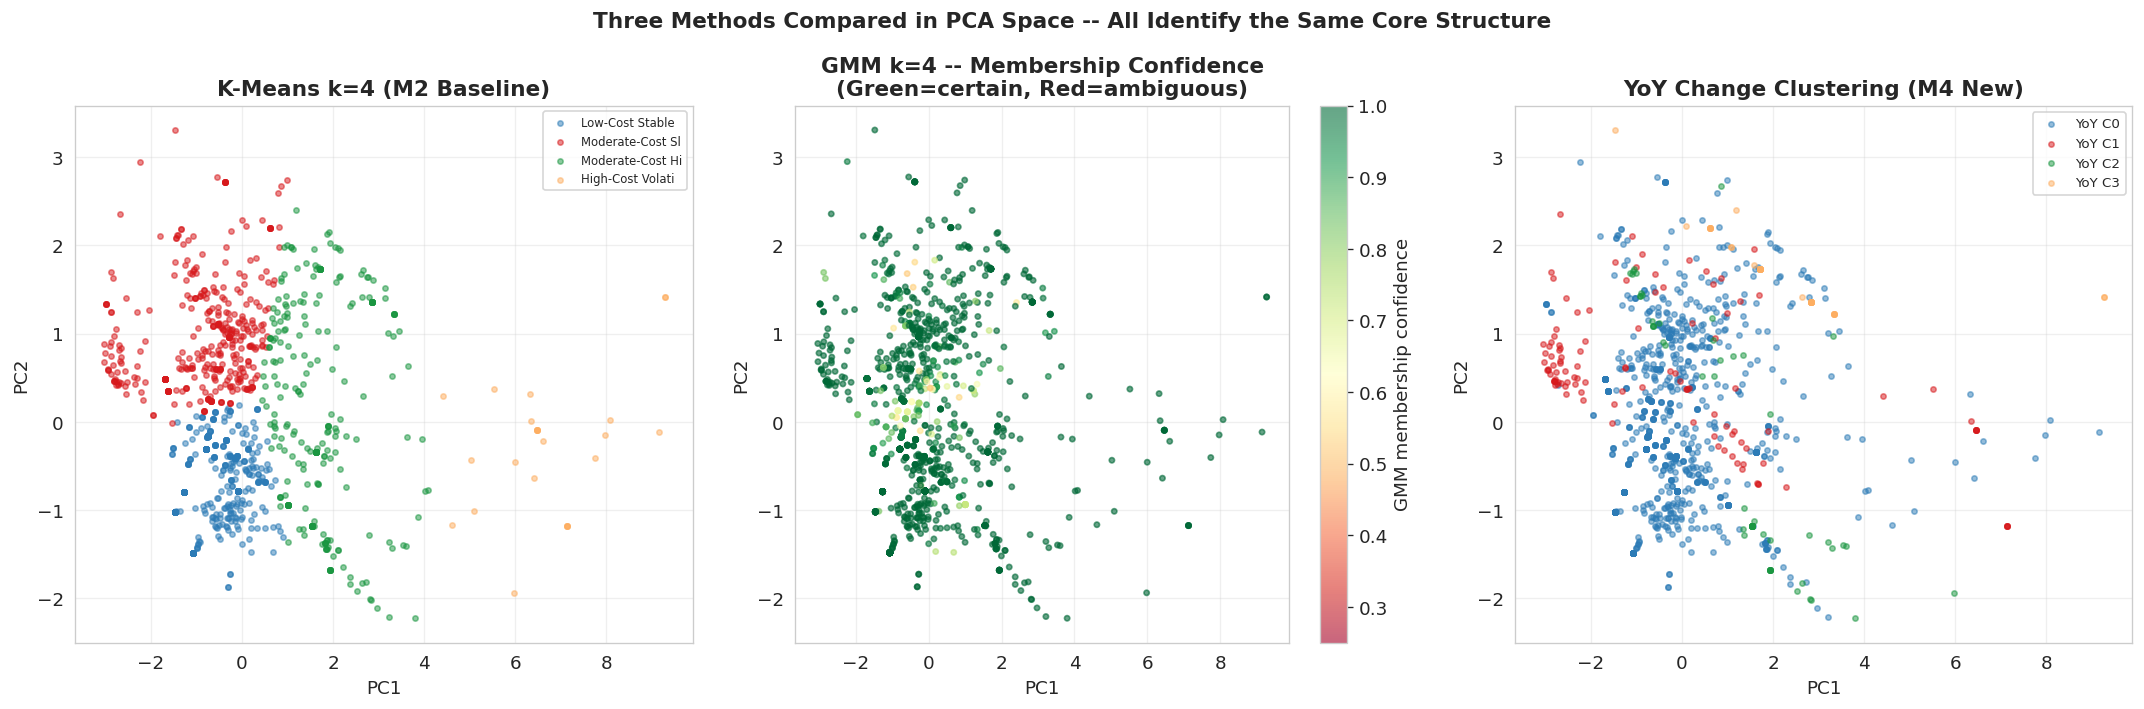

Figure 13: Final three-method comparison


In [25]:
# three-method PCA comparison
# Confirms K-Means, GMM, and YoY clustering all identify the same core structure

common_idx   = trajectory_features.index.intersection(yoy_changes.index)
traj_final   = trajectory_features.loc[common_idx, 'cluster'].values
yoy_final    = yoy_changes.loc[common_idx, 'yoy_cluster'].values
proba_final  = max_proba[trajectory_features.index.isin(common_idx)]
X_pca_final  = X_pca[trajectory_features.index.isin(common_idx)]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# K-Means k=4 (M2 baseline)
for c in range(4):
    mask = traj_final == c
    axes[0].scatter(X_pca_final[mask, 0], X_pca_final[mask, 1],
                    color=CLUSTER_COLORS[c], alpha=0.5, s=10, label=CLUSTER_LABELS[c][:16])
axes[0].set_title('K-Means k=4 (M2 Baseline)', fontweight='bold')
axes[0].legend(fontsize=7)
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')

# GMM confidence map
sc = axes[1].scatter(X_pca_final[:, 0], X_pca_final[:, 1], c=proba_final,
                     cmap='RdYlGn', alpha=0.6, s=10, vmin=0.25, vmax=1.0)
plt.colorbar(sc, ax=axes[1], label='GMM membership confidence')
axes[1].set_title('GMM k=4 -- Membership Confidence\n(Green=certain, Red=ambiguous)', fontweight='bold')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')

# YoY change clusters
for c in range(4):
    mask = yoy_final == c
    axes[2].scatter(X_pca_final[mask, 0], X_pca_final[mask, 1],
                    color=CLUSTER_COLORS[c], alpha=0.5, s=10, label=f'YoY C{c}')
axes[2].set_title('YoY Change Clustering (M4 New)', fontweight='bold')
axes[2].legend(fontsize=8)
axes[2].set_xlabel('PC1'); axes[2].set_ylabel('PC2')

fig.suptitle('Three Methods Compared in PCA Space -- All Identify the Same Core Structure',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('Figure 13: Final three-method comparison')

### What the Analyses Show

The three panels above tell a consistent story. Whether counties are grouped by their long-run cost summaries (left), by how confidently they fit a single trajectory type (middle), or by how their costs moved year-to-year (right), the same underlying structure emerges. A small group of counties expensive, fast-growing, volatile sits in the upper right of every panel. A large group of low-cost, stable counties occupies the lower left. In between is a moderate-cost majority where the boundaries are genuinely fuzzy, and where the timing of growth early in the decade versus late is the main differentiating factor.

This consistency across methods matters. If the four trajectory clusters were a statistical artefact of K-Means rather than a real feature of the data, the GMM and YoY approaches would produce different groupings. They do not. The structure is real.

**Robustness conclusion:** The near-perfect ARI across all five random seeds confirms that the four-cluster solution is not a product of a lucky initialisation it reflects genuine structure in the data. This matters for the validity of all downstream interpretations: the cluster profiles, the YoY cross-tabulation, and the GMM alignment results are all based on a stable partition, not a contingent one.

---
## 9. Findings & Interpretations

The analyses in this notebook set out to answer one question: do county-level childcare costs between 2008 and 2018 follow heterogeneous long-run trajectories, even among counties that start at similar cost levels? The answer is clearly yes and the depth of that heterogeneity is more striking than the aggregate national trend suggests.

### What This Means for Families and Policymakers

The national average childcare cost rose from roughly 90 dollars to 112 dollars per week between 2008 and 2018. That number hides more than it reveals. A family in a High-Cost Volatile county saw costs go from around 150 dollars to over 280 dollars. Nearly doubling in a decade. A family in a Low-Cost Stable county saw costs move from 65 dollars to 80 dollars. These families live in the same country, use the same type of service, and are counted in the same national statistic. But their economic realities are entirely different.

The most actionable finding is in the middle clusters. The Moderate-Cost High-Growth counties, around 550 counties that started at average cost levels in 2008, are on a trajectory toward the high-cost group. They are not yet in crisis, but they are heading there. A family there today faces a different future than a family in the Moderate-Cost Slow-Growth counties, even though both groups look similar right now. Identifying those counties *before* they become expensive is exactly what trajectory-based analysis offers that a single-year snapshot cannot.

The GMM soft membership finding adds one further layer: roughly 15% of counties sit at the boundary between trajectory types. Policies built around the four cluster archetypes will be a poor fit for them, they may need more locally-tailored approaches rather than programmes designed for one trajectory type.

### What Was Confirmed, What Was Challenged

The central assumption from M2 that long-run trajectory differences are structural and persistent is confirmed from multiple directions. The Year over Year clustering independently replicates the M2 groupings. The robustness check shows the four-cluster solution is stable across initialisations. The GMM corroborates k=4 without being told to look for four groups.

What was challenged and refined: the assumption that summary features (mean cost, growth, volatility, slope) are a complete picture of trajectory shape. They are close to complete the moderate-to-high ARI between summary clusters and Year over Year clusters confirms this, but the Year over Year approach reveals that when growth happened varies across counties in ways the summaries average away. For identifying trajectory archetypes, the summaries are sufficient. For understanding whether a county's pressure built early or late in the decade, the change vectors add genuine information.

Final Conclusion : Counties follow heterogeneous long-run trajectories. The heterogeneity is structural, stable, and visible from multiple analytical angles. It matters for families, for policy design, and for any organisation trying to understand where childcare affordability pressure is coming from and where it is headed.


## **Generative AI Disclosure :**  
Chatgpt Pro was used as a support tool throughout this milestone for the following purposes:

Conceptual clarification: Understanding the mechanics of DBSCAN, Gaussian Mixture Models, Adjusted Rand Index, silhouette analysis, and Dynamic Time Warping (i was considering exploring DTW, but decided to retain K-Means over DTW), and how they apply to trajectory clustering problems.

Python syntax and debugging: Assistance with some visualisation codes (the spaghetti plot esp), sklearn model fitting, index alignment issues, and parameter sweep structure.

The in-built Gemini fuction was used to debug a code

Writing refinement: Helped me articulate analytical interpretations and findings in clear, structured language in the document and also help me make the document concise to meet the page limit .

**GenAI link:** https://chatgpt.com/share/699d1a58-5bd4-8006-9e29-169475c459d8
